In [1]:
import os
import math
import wandb
import random
import time
import logging
import inspect
import argparse
import datetime
import numpy as np

from pathlib import Path
from tqdm.auto import tqdm
from einops import rearrange, repeat
from omegaconf import OmegaConf
from typing import Dict, Optional, Tuple

import torch
import torch.nn.functional as F
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader

import diffusers
from diffusers import AutoencoderKL, DDIMScheduler
from diffusers.optimization import get_scheduler
from diffusers.utils import check_min_version
from diffusers.utils.import_utils import is_xformers_available
from diffusers.training_utils import EMAModel

import transformers
from transformers import CLIPTextModel, CLIPTokenizer

from accelerate import Accelerator, DistributedDataParallelKwargs, InitProcessGroupKwargs
from accelerate.logging import get_logger
from accelerate.utils import set_seed

from swomo.data.dataset import SurgicalDataset
from swomo.models.videoldm_unet import VideoLDMUNet3DConditionModel
from swomo.models.videoldm_controlnet import ControlNetModel
from swomo.graph_encoder.graph_segclip_masked import GraphEncoder
from swomo.pipelines.pipeline_conditional_animation import ConditionalAnimationPipeline
from swomo.pipelines.pipeline_controlnet_animation import ControlNetAnimationPipeline
from swomo.utils.util import save_videos_grid, save_videos_grid_from_paths
from swomo.utils.get_scene_graph import GraphConstructor




import matplotlib.pyplot as plt
from PIL import Image


/home/MichalMo/anaconda3/envs/swomo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/MichalMo/anaconda3/envs/swomo/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.0'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [25]:
# parser = argparse.ArgumentParser()
# parser.add_argument("--config",   type=str, required=True)
# parser.add_argument("--name", "-n", type=str, default="")
# parser.add_argument("--wandb",    action="store_true")
# parser.add_argument("optional_args", nargs='*', default=[])
# args = parser.parse_args()

# name   = args.name + "_" + Path(args.config).stem



config = OmegaConf.load("configs/training/training_img_graph_vid_cataracts.yaml")

print(config.train_data)
train_dataset = SurgicalDataset(**config.train_data, train_graph_encoder = False)


{'dataset': 'surgical', 'dataset_name': 'cataract', 'video_folder': ['datasets/Cataract-1K'], 'class_size': 14, 'split_mode': 'train', 'return_graph_emb': True, 'return_cond_videos': True, 'sample_size': 128, 'sample_n_frames': 16, 'apply_augmentation': False, 'embedding_type': 'combined', 'model_masked': './checkpoints/Cataract-1K/graphencoder_masked/best_val_loss.pth', 'model_segclip': './checkpoints/Cataract-1K/graphencoder_segclip/best_val_loss.pth', 'graph_input_dim': 20, 'graph_hidden_dim': 256, 'graph_embedding_dim': 256, 'trainable': False, 'graph_conv_type': 'GATv2Conv', 'graph_norm_type': 'LayerNorm'}


In [26]:
train_dataset.train_graph_encoder

False

In [27]:

config = OmegaConf.load("configs/training/training_img_graph_xvid_cataracts.yaml")

print(config.train_data)
train_dataset_xvid = SurgicalDataset(**config.train_data)

{'dataset': 'surgical', 'dataset_name': 'cataract', 'video_folder': ['datasets/Cataract-1K'], 'class_size': 14, 'split_mode': 'train', 'return_graph_emb': True, 'return_cond_videos': False, 'sample_size': 128, 'sample_n_frames': 16, 'apply_augmentation': False, 'embedding_type': 'combined', 'model_masked': './checkpoints/Cataract-1K/graphencoder_masked/best_val_loss.pth', 'model_segclip': './checkpoints/Cataract-1K/graphencoder_segclip/best_val_loss.pth', 'graph_input_dim': 20, 'graph_hidden_dim': 256, 'graph_embedding_dim': 256, 'trainable': False, 'graph_conv_type': 'GATv2Conv', 'graph_norm_type': 'LayerNorm'}


In [52]:
train_dataset_xvid.train_graph_encoder

False

In [40]:
print(len(train_dataset))
print(train_dataset.sample[0])

train_dataloader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=4,
    num_workers=1,
    pin_memory=True,
)

# print(len(train_dataset))
# print(train_dataset.sample[0])

train_dataloader_xvid = DataLoader(
    train_dataset_xvid,
    shuffle=True,
    batch_size=4,
    num_workers=1,
    pin_memory=True,
)

540384
{'video': 'case_2000', 'video_folder': 'datasets/Cataract-1K', 'frame': ['0000000000.jpg', '0000000002.jpg', '0000000004.jpg', '0000000006.jpg', '0000000008.jpg', '0000000010.jpg', '0000000012.jpg', '0000000014.jpg', '0000000016.jpg', '0000000018.jpg', '0000000020.jpg', '0000000022.jpg', '0000000024.jpg', '0000000026.jpg', '0000000028.jpg', '0000000030.jpg', '0000000032.jpg'], 'segm': ['datasets/Cataract-1K/masks_sim/case_2000/0000000000.png', 'datasets/Cataract-1K/masks_sim/case_2000/0000000002.png', 'datasets/Cataract-1K/masks_sim/case_2000/0000000004.png', 'datasets/Cataract-1K/masks_sim/case_2000/0000000006.png', 'datasets/Cataract-1K/masks_sim/case_2000/0000000008.png', 'datasets/Cataract-1K/masks_sim/case_2000/0000000010.png', 'datasets/Cataract-1K/masks_sim/case_2000/0000000012.png', 'datasets/Cataract-1K/masks_sim/case_2000/0000000014.png', 'datasets/Cataract-1K/masks_sim/case_2000/0000000016.png', 'datasets/Cataract-1K/masks_sim/case_2000/0000000018.png', 'datasets/Cata

In [45]:
train_dataset.sample[0]

{'video': 'case_2000',
 'video_folder': 'datasets/Cataract-1K',
 'frame': ['0000000000.jpg',
  '0000000002.jpg',
  '0000000004.jpg',
  '0000000006.jpg',
  '0000000008.jpg',
  '0000000010.jpg',
  '0000000012.jpg',
  '0000000014.jpg',
  '0000000016.jpg',
  '0000000018.jpg',
  '0000000020.jpg',
  '0000000022.jpg',
  '0000000024.jpg',
  '0000000026.jpg',
  '0000000028.jpg',
  '0000000030.jpg',
  '0000000032.jpg'],
 'segm': ['datasets/Cataract-1K/masks_sim/case_2000/0000000000.png',
  'datasets/Cataract-1K/masks_sim/case_2000/0000000002.png',
  'datasets/Cataract-1K/masks_sim/case_2000/0000000004.png',
  'datasets/Cataract-1K/masks_sim/case_2000/0000000006.png',
  'datasets/Cataract-1K/masks_sim/case_2000/0000000008.png',
  'datasets/Cataract-1K/masks_sim/case_2000/0000000010.png',
  'datasets/Cataract-1K/masks_sim/case_2000/0000000012.png',
  'datasets/Cataract-1K/masks_sim/case_2000/0000000014.png',
  'datasets/Cataract-1K/masks_sim/case_2000/0000000016.png',
  'datasets/Cataract-1K/masks

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


dict_keys(['graph', 'image', 'class_label', 'segmentation'])
torch.Size([16, 128, 128, 3])
torch.Size([16, 128, 128, 14]) (array([0., 1.], dtype=float32), array([3407872,  262144]))
torch.Size([4, 14]) tensor([[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0],
        [1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0]])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


dict_keys(['graph', 'image', 'class_label', 'segmentation'])
torch.Size([16, 128, 128, 3])
torch.Size([16, 128, 128, 14]) (array([0., 1.], dtype=float32), array([3407872,  262144]))
torch.Size([4, 14]) tensor([[1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]])


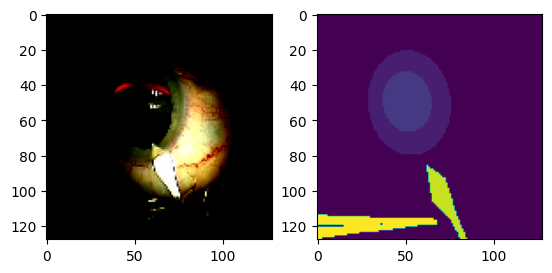

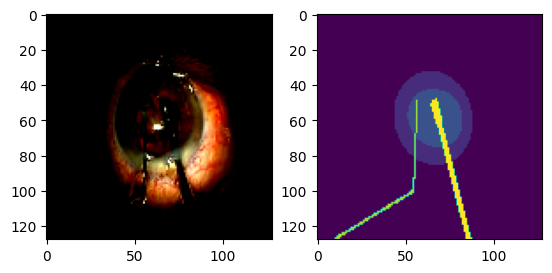

In [54]:
for step, batch in enumerate(train_dataloader):

    print(batch.keys())


    pixel_values = batch["image"]
    pixel_values = rearrange(pixel_values, "b f c h w -> b f h w c")[0]

    print(pixel_values.shape)


    mask = batch["segmentation"]
    mask = rearrange(mask, "b f c h w -> b f h w c")[0]
    masks_label_map = np.argmax(mask, axis=-1)#.astype(np.float32)

    print(mask.shape, np.unique(mask, return_counts=1))

    print(batch["class_label"].shape, batch["class_label"])

    plt.figure()
    plt.subplot(121)

    plt.imshow(np.array(pixel_values[0]).astype(np.float32))


    plt.subplot(122)
    plt.imshow(masks_label_map[0])




    if step ==1:
        break

In [51]:
for step, batch in enumerate(train_dataloader_xvid):

    print(batch.keys())


    pixel_values = batch["pixel_values"]
    pixel_values = rearrange(pixel_values, "b f c h w -> b f h w c")[0]

    print(pixel_values.shape)


    mask = batch["segm"]
    print(mask.shape, np.unique(mask, return_counts=1))


    if step ==1:
        break

dict_keys(['graph', 'pixel_values', 'cond_video_values', 'text', 'first_frame_path', 'all_frame_path', 'cond_video_path'])
torch.Size([16, 128, 128, 3])


KeyError: 'segm'

In [21]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

def analyze_masks(base_folder):
    base_dir = Path(base_folder)
    all_cases_data = []

    # Common image extensions (adjust if your masks use a different format)
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}

    # 1) Iterate over subfolders
    for i,case_folder in enumerate(base_dir.glob("case_*")):
        if not case_folder.is_dir():
            continue
            

        if i == 1:
            break
        case_name = case_folder.name
        
        # Gather all image paths in the current subfolder
        image_paths = [
            p for p in case_folder.iterdir() 
            if p.is_file() and p.suffix.lower() in valid_extensions
        ]
        
        num_images = len(image_paths)
        if num_images == 0:
            print(f"Warning: No images found in {case_name}. Skipping.")
            continue

        case_class_counts = {}
        total_pixels = 0

        # Iterate over images in the subfolder
        for img_path in image_paths:
            # Read image unchanged to preserve exact mask/pixel values
            img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
            
            if img is None:
                print(f"Warning: Could not read {img_path}")
                continue

            # Calculate unique classes and their pixel counts in this image
            unique_classes, counts = np.unique(img, return_counts=True)
            print("unique_classes ", unique_classes)

            # Accumulate counts for the whole case
            for cls, count in zip(unique_classes, counts):
                case_class_counts[cls] = case_class_counts.get(cls, 0) + count
                total_pixels += count

        # If no valid pixels were read, skip to avoid division by zero
        if total_pixels == 0:
            continue

        # 2) Construct data dictionary for this specific case
        case_data = {
            "case_name": case_name,
            "number_of_images": num_images,
            "number_of_unique_classes": len(case_class_counts)
        }

        # Calculate percentage surface for each unique class
        for cls, count in case_class_counts.items():
            percentage = (count / total_pixels) * 100
            case_data[f"class_{cls}_pct"] = percentage

        all_cases_data.append(case_data)

    # Compile the final pandas DataFrame
    df = pd.DataFrame(all_cases_data)
    
    # Sort by case name for better readability
    df.sort_values(by="case_name", inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    # Fill NaN values with 0. 
    # (If Class X exists in case_2000 but not case_2001, case_2001 will initially have NaN)
    df.fillna(0, inplace=True)

    return df

# --- Execution ---
if __name__ == "__main__":
    folder_path = "datasets/Cataract-1K/masks_sim"
    
    # Check if directory exists before running
    if not os.path.exists(folder_path):
        print(f"Error: The directory '{folder_path}' does not exist.")
    else:
        results_df = analyze_masks(folder_path)
        
        # Display the first few rows
        print(results_df.head())
        
        # Optional: Save to CSV
        # results_df.to_csv("mask_analysis_results.csv", index=False)

unique_classes  [  0  24  50  53  85 103 116 155 175 223 230]
unique_classes  [  0  50  53 116 175 223 230]
unique_classes  [  0  50  53 116 130 175 180 223 230 242]
unique_classes  [  0  24  50  53  85 103 116 155 175 223 230]
unique_classes  [  0  50  53 112 116 152 175 204 223 230]
unique_classes  [  0  50  53 116 175 223 230]
unique_classes  [  0  24  50  53  85 103 116 155 175 223 230]
unique_classes  [  0  50  53 112 116 152 175 204 223 230]
unique_classes  [  0  50  53 116 130 175 180 223 230 242]
unique_classes  [  0  24  50  53  85 103 116 155 175 223 230]
unique_classes  [  0  24  50  53  85 103 116 155 175 223 230]
unique_classes  [  0  50  53 112 116 152 175 204 223 230]
unique_classes  [  0  50  53 116 130 175 180 223 230 242]
unique_classes  [  0  24  50  53  85 103 116 155 175 223 230]
unique_classes  [  0  50  53 116 130 175 180 223 230 242]
unique_classes  [  0  24  50  53  85 103 116 155 175 223 230]
unique_classes  [  0  24  50  53  85 103 116 155 175 223 230]
unique

In [5]:
results_df.head()

,case_name,number_of_images,number_of_unique_classes,class_0_pct,class_24_pct,class_50_pct,class_53_pct,class_85_pct,class_103_pct,class_116_pct,...,class_152_pct,class_204_pct,class_41_pct,class_149_pct,class_164_pct,class_167_pct,class_238_pct,class_70_pct,class_197_pct,class_221_pct
0,case_2286,1040,25,86.289994,0.093686,2.714531,2.714531,0.189231,0.096244,1.596747,...,0.03146,0.03146,0.002558,0.006833,0.006833,0.006833,0.002558,0.009318,0.009318,0.009318


datasets/Cataract-1K/video_frames_jpg/case_2286/0000000977.jpg
datasets/Cataract-1K/masks_sim/case_2286/0000000977.png


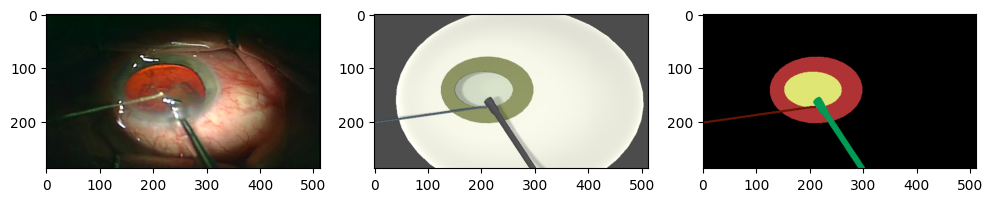

datasets/Cataract-1K/video_frames_jpg/case_2286/0000000282.jpg
datasets/Cataract-1K/masks_sim/case_2286/0000000282.png


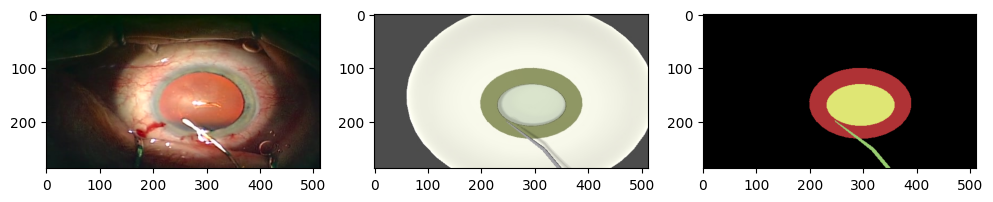

datasets/Cataract-1K/video_frames_jpg/case_2286/0000000698.jpg
datasets/Cataract-1K/masks_sim/case_2286/0000000698.png


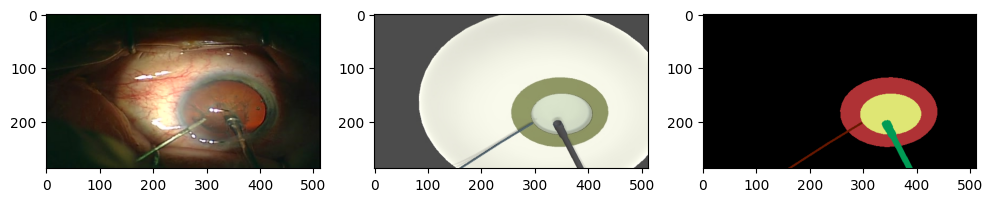

datasets/Cataract-1K/video_frames_jpg/case_2286/0000000710.jpg
datasets/Cataract-1K/masks_sim/case_2286/0000000710.png


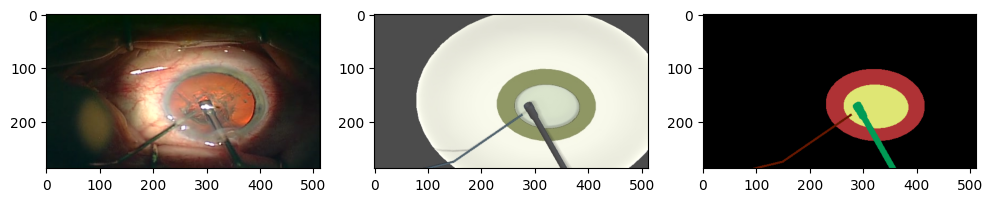

datasets/Cataract-1K/video_frames_jpg/case_2286/0000000878.jpg
datasets/Cataract-1K/masks_sim/case_2286/0000000878.png


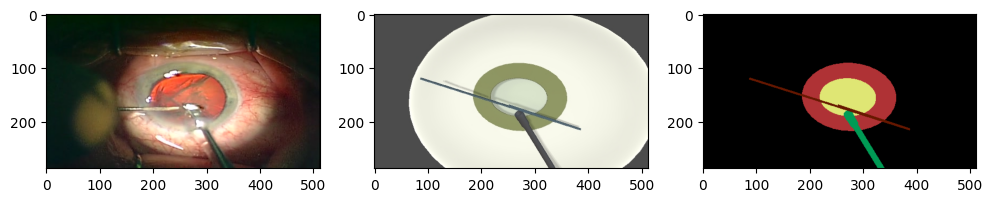

In [20]:
base_folder = "datasets/Cataract-1K/video_frames_jpg"

base_dir = Path(base_folder)
all_cases_data = []

# Common image extensions (adjust if your masks use a different format)
valid_extensions = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}

# 1) Iterate over subfolders
for i,case_folder in enumerate(base_dir.glob("case_*")):
    if not case_folder.is_dir():
        continue
        

    if i == 1:
        break
    case_name = case_folder.name
    
    # Gather all image paths in the current subfolder
    image_paths = [
        p for p in case_folder.iterdir() 
        if p.is_file() and p.suffix.lower() in valid_extensions
    ]
    
    num_images = len(image_paths)
    if num_images == 0:
        print(f"Warning: No images found in {case_name}. Skipping.")
        continue

    case_class_counts = {}
    total_pixels = 0

    # Iterate over images in the subfolder
    for img_path in image_paths[:5]:
        print(img_path)
        # Read image unchanged to preserve exact mask/pixel values
        img = Image.open(img_path)

        img_path2 = str(img_path)
        img_path2 = img_path2.replace("jpg", "sim", 1)
        mask = Image.open(img_path2)



        maskpath = str(img_path2)
        maskpath = maskpath.replace("video_frames_sim", "masks_sim", 1)
        maskpath = maskpath.replace("jpg", "png")
        mask2 = Image.open(maskpath)

        print(maskpath)



        plt.figure(figsize=(12,4))
        plt.subplot(131)

        plt.imshow(img)


        plt.subplot(132)
        plt.imshow(mask)

        plt.subplot(133)
        plt.imshow(mask2)

        plt.show()

# target_path = "datasets/Cataract-1K/video_frames_jpg/case_2005/0000000001.jpg"

# mask = Image.open(target_path)



# mask = np.asarray(mask)
# print(mask.shape)
# # print(np.unique(mask, return_counts=1))

# plt.imshow(mask)
            

In [24]:
c =0
for x in base_dir.glob("case_*"):
    c = c+1

c

1068